# Import Library: 분석에 사용할 모듈 설치
**1. Import Library**

In [1]:
!python -m pip install --user --upgrade pip

In [2]:
# Ignore the warnings
import warnings
# warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

# System related and data input controls
import os

# Data manipulation and visualization
from sklearn.datasets import fetch_california_housing
import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_rows = 20
pd.options.display.max_columns = 20
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn import preprocessing

# Modeling algorithms
# General
import statsmodels.api as sm
from scipy import stats
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.get_logger().warning('test')
import tensorflow_addons as tfa
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Input, Dense, Activation, Flatten, Dropout, Reshape
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU
from tensorflow.keras.utils import plot_model

# Model selection
from sklearn.model_selection import train_test_split, TimeSeriesSplit

# Evaluation metrics
from sklearn import metrics

In [3]:
def reshape_1Dto2Dseq(df, seq_length):
    # 2D X & Y split
    X_reshape, Y_reshape = [], []
    for index in range(len(df) - seq_length): # 2D: seq_length+1
        X_reshape.append(np.array(df[index: index + seq_length]))
        Y_reshape.append(np.ravel(df[index + seq_length:index + seq_length + 1])) # 2D(first): seq_length-1
    X_reshape, Y_reshape = np.array(X_reshape), np.array(Y_reshape)    
    
    # reshape
    X_reshape = pd.DataFrame(X_reshape.reshape(X_reshape.shape[0], -1), index=df.index[seq_length:])
    Y_reshape = pd.DataFrame(Y_reshape, columns=df.columns, index=df.index[seq_length:])
    
    return X_reshape, Y_reshape


def datasplit_cross_traintest(df, Y_colname, test_ratio, 
                              random_seed=123, shape_show=True):
    # setting
    X_colname = [i for i in df.columns if i not in Y_colname]
    
    # train / test / X / Y split
    X_train, X_test, Y_train, Y_test = train_test_split(df[X_colname], 
                                                        df[Y_colname], 
                                                        test_size=test_ratio,
                                                        random_state=random_seed)
    
    # result
    if shape_show:
        print('X_train:', X_train.shape, 'Y_train:', Y_train.shape)
        print('X_test:', X_test.shape, 'Y_test:', Y_test.shape)
    
    return X_train, X_test, Y_train, Y_test


def datasplit_timeseries_ratio(df, Y_colname, test_ratio=0.4, 
                               shape_show=True):
    # setting
    test_size = int(df.shape[0] * test_ratio)
    
    # train / test split
    df_train = df.iloc[:-test_size,:]
    df_test = df.iloc[-test_size:,:]
    
    # X / Y split
    X_colname = [i for i in df.columns if i not in Y_colname]
    Y_train = df_train[Y_colname]
    X_train = df_train[X_colname]
    Y_test = df_test[Y_colname]
    X_test = df_test[X_colname]
    
    # result
    if shape_show:
        print('X_train:', X_train.shape, 'Y_train:', Y_train.shape)
        print('X_test:', X_test.shape, 'Y_test:', Y_test.shape)
    
    return X_train, X_test, Y_train, Y_test


def reshape_2Dto3Dseq(df_X, df_Y, seq_length):
    # generate sequence
    X_reshape, Y_reshape = [], []
    for index in range(len(df_X) - seq_length + 1):
        X_reshape.append(np.array(df_X[index: index + seq_length]))
        Y_reshape.append(np.ravel(df_Y[index + seq_length - 1:index + seq_length]))
    X_reshape, Y_reshape = np.array(X_reshape), np.array(Y_reshape)
    
    # reshape
    X_reshape = X_reshape.reshape(X_reshape.shape[0], seq_length, -1)
    Y_reshape = pd.DataFrame(Y_reshape, index=df_Y.index[seq_length-1:], columns=df_Y.columns)
    
    return X_reshape, Y_reshape


# Learning Plot
def evaluation_reg_LearningPlot(fit_class, figsize=(10,3), 
                            label_first='Training', label_second='Validation'):
    for i in range(int(len(fit_class.history.keys())/2)):
        if i == 0:
            # Loss Plot
            plt.figure(figsize=figsize)
            plt.plot(fit_class.history['loss'], color='b', 
                     label=label_first+' Loss')
            plt.plot(fit_class.history['val_loss'], color='r', 
                     label=label_second+' Loss')
        elif i == 1:
            # MAE Plot
            plt.figure(figsize=figsize)
            plt.plot(fit_class.history['mae'], color='b', 
                     label=label_first+' MAE')
            plt.plot(fit_class.history['val_mae'], color='r', 
                     label=label_second+' MAE')
        elif i == 2:
            # MSE Plot
            plt.figure(figsize=figsize)
            plt.plot(fit_class.history['mse'], color='b', 
                     label=label_first+' MSE')
            plt.plot(fit_class.history['val_mse'], color='r', 
                     label=label_second+' MSE')
        else:
            # MAPE Plot
            plt.figure(figsize=figsize)
            plt.plot(fit_class.history['mape'], color='b', 
                     label=label_first+' MAPE')
            plt.plot(fit_class.history['val_mape'], color='r', 
                     label=label_second+' MAPE')
        plt.xlabel('Epoch', fontsize=15)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.legend(loc='best', shadow=True, fontsize=12)
        plt.show()
        
        
def evaluation_reg_MAE_MSE_MAPE(Y_real, Y_pred):
    # length check
    loss_length = len(Y_real.values.flatten()) - len(Y_pred)
    if loss_length != 0:
        Y_real = Y_real[loss_length:]
    
    # evaluator
    MAE = metrics.mean_absolute_error(Y_real, Y_pred)
    MSE = metrics.mean_squared_error(Y_real, Y_pred)
    MAPE = metrics.mean_absolute_percentage_error(Y_real, Y_pred)
    
    # rearrange
    Score = pd.DataFrame([MAE, MSE, MAPE], index=['MAE', 'MSE', 'MAPE'], columns=['Score']).T
    Residual = Y_real - Y_pred
    
    return Score, Residual
        
        
def evaluation_reg_PredPlot(Y_real, Y_pred, title='Algorithm',
                        xlabel='Sequence', ylabel='Price'):
    df_Y = pd.concat([Y_real, pd.DataFrame(Y_pred, 
                                           index=Y_real.index)], axis=1)
    df_Y.columns = ['Real Value', 'Predicted Value']
    df_Y.plot(kind='line', figsize=(18,6), linewidth=3, fontsize=20,
              xlim=(Y_real.index.min(),Y_real.index.max()))
    plt.title(title, fontsize=20)
    plt.xlabel(xlabel, fontsize=20)
    plt.ylabel(ylabel, fontsize=20)
    plt.legend(fontsize=16)
    plt.grid()
    plt.show()


def stationarity_adf_test(Y_Data, Target_name):
    if len(Target_name) == 0:
        Stationarity_adf = pd.Series(sm.tsa.stattools.adfuller(Y_Data)[0:4],
                                     index=['Test Statistics', 'p-value', 'Used Lag', 'Used Observations'])
        for key, value in sm.tsa.stattools.adfuller(Y_Data)[4].items():
            Stationarity_adf['Critical Value(%s)'%key] = value
            Stationarity_adf['Maximum Information Criteria'] = sm.tsa.stattools.adfuller(Y_Data)[5]
            Stationarity_adf = pd.DataFrame(Stationarity_adf, columns=['Stationarity_adf'])
    else:
        Stationarity_adf = pd.Series(sm.tsa.stattools.adfuller(Y_Data[Target_name])[0:4],
                                     index=['Test Statistics', 'p-value', 'Used Lag', 'Used Observations'])
        for key, value in sm.tsa.stattools.adfuller(Y_Data[Target_name])[4].items():
            Stationarity_adf['Critical Value(%s)'%key] = value
            Stationarity_adf['Maximum Information Criteria'] = sm.tsa.stattools.adfuller(Y_Data[Target_name])[5]
            Stationarity_adf = pd.DataFrame(Stationarity_adf, columns=['Stationarity_adf'])
    return Stationarity_adf


def stationarity_kpss_test(Y_Data, Target_name):
    if len(Target_name) == 0:
        Stationarity_kpss = pd.Series(sm.tsa.stattools.kpss(Y_Data)[0:3],
                                      index=['Test Statistics', 'p-value', 'Used Lag'])
        for key, value in sm.tsa.stattools.kpss(Y_Data)[3].items():
            Stationarity_kpss['Critical Value(%s)'%key] = value
            Stationarity_kpss = pd.DataFrame(Stationarity_kpss, columns=['Stationarity_kpss'])
    else:
        Stationarity_kpss = pd.Series(sm.tsa.stattools.kpss(Y_Data[Target_name])[0:3],
                                      index=['Test Statistics', 'p-value', 'Used Lag'])
        for key, value in sm.tsa.stattools.kpss(Y_Data[Target_name])[3].items():
            Stationarity_kpss['Critical Value(%s)'%key] = value
            Stationarity_kpss = pd.DataFrame(Stationarity_kpss, columns=['Stationarity_kpss'])
    return Stationarity_kpss


def error_analysis(Y_Data, X_Data, graph_on=False):
#     X_Data = X_Data.loc[Y_Data.index] # for Bitcoin

    if graph_on == True:
        ##### Error Analysis(Plot)
        Y_Data['RowNum'] = Y_Data.reset_index().index

        # Stationarity(Trend) Analysis
        sns.set(palette="muted", color_codes=True, font_scale=2)
        sns.lmplot(x='RowNum', y=Y_Data.columns[0], data=Y_Data, line_kws={'color': 'red'},
                   fit_reg='True', size=5.2, aspect=2, ci=99, sharey=True)
        del Y_Data['RowNum']

        # Normal Distribution Analysis
        figure, axes = plt.subplots(figsize=(12,8))
        sns.distplot(Y_Data[Y_Data.columns[0]], norm_hist='True', fit=stats.norm, ax=axes)

        # Lag Analysis
        length = int(len(Y_Data[Y_Data.columns[0]])/10)
        figure, axes = plt.subplots(1, 4, figsize=(12,3))
        pd.plotting.lag_plot(Y_Data[Y_Data.columns[0]], lag=1, ax=axes[0])
        pd.plotting.lag_plot(Y_Data[Y_Data.columns[0]], lag=5, ax=axes[1])
        pd.plotting.lag_plot(Y_Data[Y_Data.columns[0]], lag=10, ax=axes[2])
        pd.plotting.lag_plot(Y_Data[Y_Data.columns[0]], lag=50, ax=axes[3])

        # Autocorrelation Analysis
        figure, axes = plt.subplots(2,1,figsize=(12,5))
        sm.tsa.graphics.plot_acf(Y_Data[Y_Data.columns[0]], lags=50, use_vlines=True, ax=axes[0])
        sm.tsa.graphics.plot_pacf(Y_Data[Y_Data.columns[0]], lags=50, use_vlines=True, ax=axes[1])

    ##### Error Analysis(Statistics)
    # Checking Stationarity
    # Null Hypothesis: The Time-series is non-stationalry
    Stationarity_adf = stationarity_adf_test(Y_Data, Y_Data.columns[0])
    Stationarity_kpss = stationarity_kpss_test(Y_Data, Y_Data.columns[0])

    # Checking of Normality
    # Null Hypothesis: The residuals are normally distributed
    Normality = pd.DataFrame([stats.shapiro(Y_Data[Y_Data.columns[0]])],
                             index=['Normality'], columns=['Test Statistics', 'p-value']).T

    # Checking for Autocorrelation
    # Null Hypothesis: Autocorrelation is absent
    Autocorrelation = pd.concat([pd.DataFrame(sm.stats.diagnostic.acorr_ljungbox(Y_Data[Y_Data.columns[0]], lags=[1,5,10,50])[0], columns=['Test Statistics']),
                                 pd.DataFrame(sm.stats.diagnostic.acorr_ljungbox(Y_Data[Y_Data.columns[0]], lags=[1,5,10,50])[1], columns=['p-value'])], axis=1).T
    Autocorrelation.columns = ['Autocorr(lag1)', 'Autocorr(lag5)', 'Autocorr(lag10)', 'Autocorr(lag50)']

    # Checking Heteroscedasticity
    # Null Hypothesis: Error terms are homoscedastic
    Heteroscedasticity = pd.DataFrame([sm.stats.diagnostic.het_goldfeldquandt(Y_Data[Y_Data.columns[0]], X_Data.values, alternative='two-sided')],
                                      index=['Heteroscedasticity'], columns=['Test Statistics', 'p-value', 'Alternative']).T
    Score = pd.concat([Stationarity_adf, Stationarity_kpss, Normality, Autocorrelation, Heteroscedasticity], join='outer', axis=1)
    index_new = ['Test Statistics', 'p-value', 'Alternative', 'Used Lag', 'Used Observations',
                 'Critical Value(1%)', 'Critical Value(5%)', 'Critical Value(10%)', 'Maximum Information Criteria']
    Score.reindex(index_new)
    
    return Score

# Deep Learning: Bitcoin Prediction

## Parameters Setting

In [4]:
Y_colname = ['Bitcoin']
scaler = preprocessing.MinMaxScaler()
tf.random.set_seed(123)
TEST_RATIO = 0.1
SEQUENCE = 20 # not MLP
DROPOUT_RATIO = 0.2
BATCH_SIZE = 32
EPOCHS = 20 # 100
VERBOSE = 0
# Callback WalkForward
EARLYSTOP_PATIENT = 10
CALLBACK = tfa.callbacks.TQDMProgressBar(show_epoch_progress=False)
#################
RESULT_LOCATION = os.path.join(os.getcwd(),'Result','Bitcoin_')
RESULT_DPI = 150
ALGO_NAMES = ['MLP', 'CNN', 'RNN', 'LSTM', 'GRU']

## MLP

100%|███████████████████████████████████████████████████████████████████████████████▋| 238/239 [13:40<00:03,  3.67s/it]

Model: "model_238"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_239 (InputLayer)       [(None, 20)]              0         
_________________________________________________________________
dense_714 (Dense)            (None, 128)               2688      
_________________________________________________________________
dropout_476 (Dropout)        (None, 128)               0         
_________________________________________________________________
dense_715 (Dense)            (None, 64)                8256      
_________________________________________________________________
dropout_477 (Dropout)        (None, 64)                0         
_________________________________________________________________
dense_716 (Dense)            (None, 1)                 65        
Total params: 11,009
Trainable params: 11,009
Non-trainable params: 0
_____________________________________________________

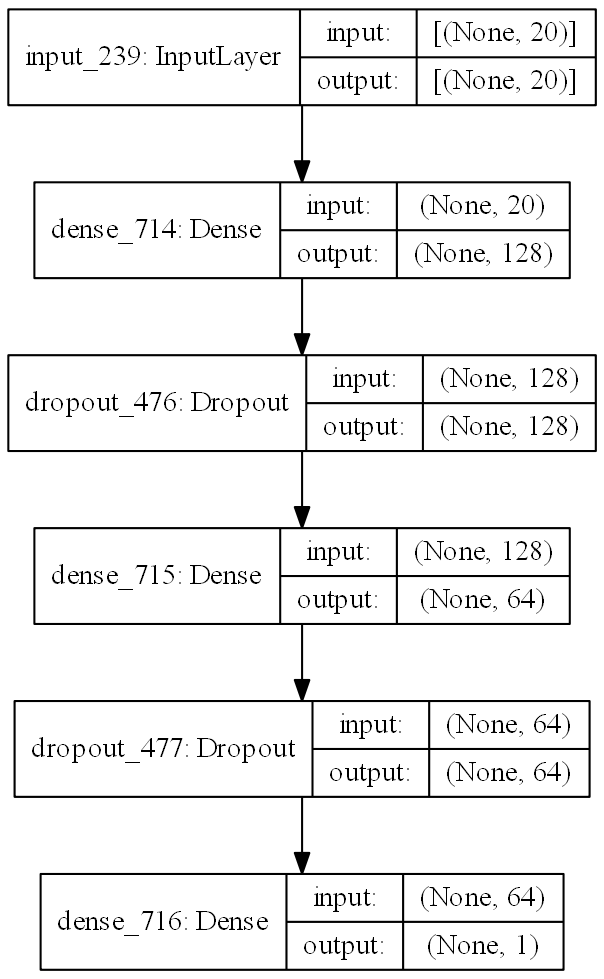

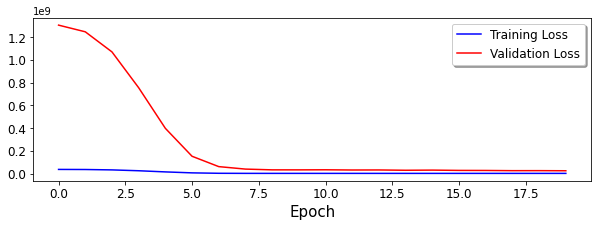

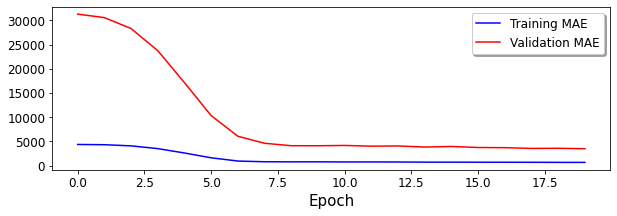

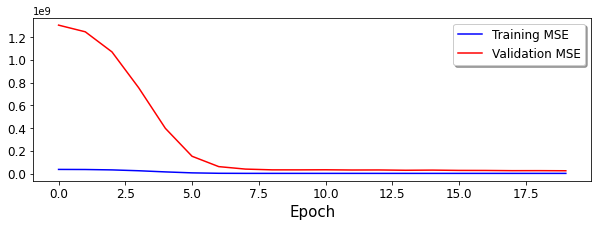

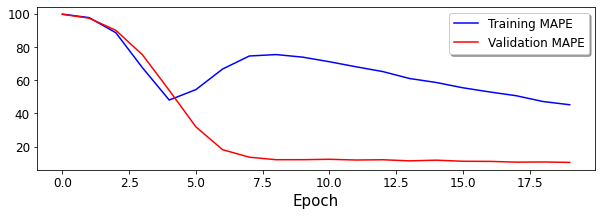

100%|████████████████████████████████████████████████████████████████████████████████| 239/239 [13:44<00:00,  3.45s/it]


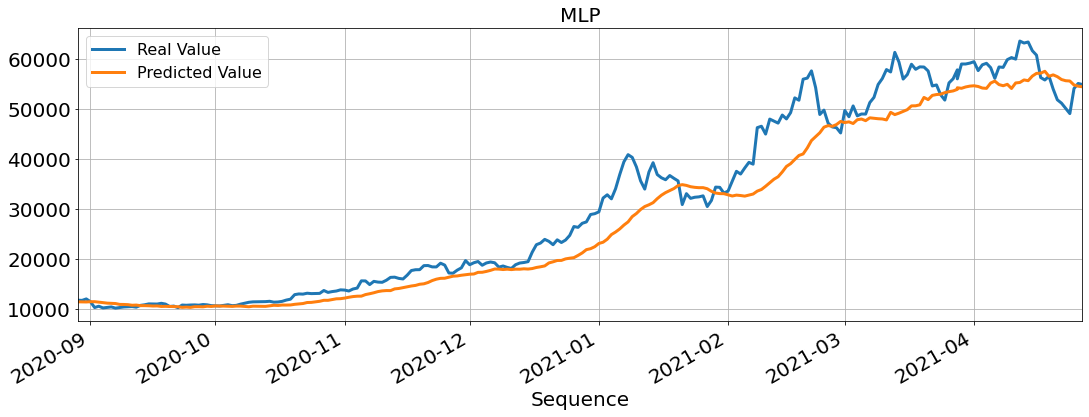

,MAE,MSE,MAPE
Score,"3,522.29","24,421,357.08",0.11


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

,Stationarity_adf,Stationarity_kpss,Normality,Autocorr(lag1),Autocorr(lag5),Autocorr(lag10),Autocorr(lag50),Heteroscedasticity
Test Statistics,-3.17,0.45,0.93,203.43,687.38,810.86,"1,060.56",16.10
p-value,0.02,0.06,0.00,0.00,0.00,0.00,0.00,0.00
Used Lag,0.00,15.00,NaN,NaN,NaN,NaN,NaN,NaN
Used Observations,238.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Critical Value(1%),-3.46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Maximum Information Criteria,"3,924.69",NaN,NaN,NaN,NaN,NaN,NaN,NaN
Critical Value(10%),NaN,0.35,NaN,NaN,NaN,NaN,NaN,NaN
Alternative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,two-sided


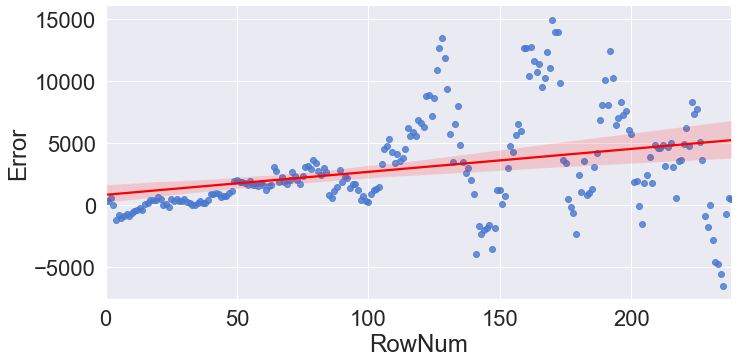

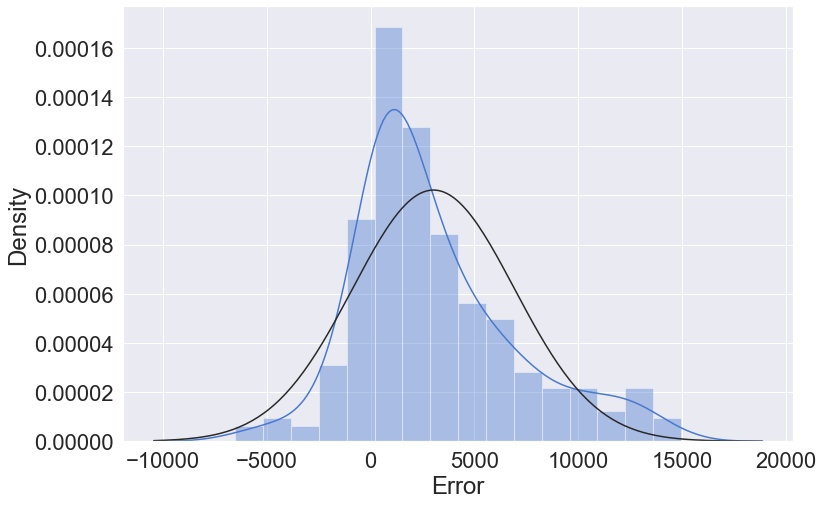

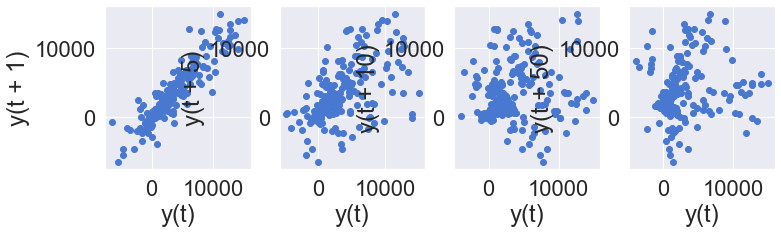

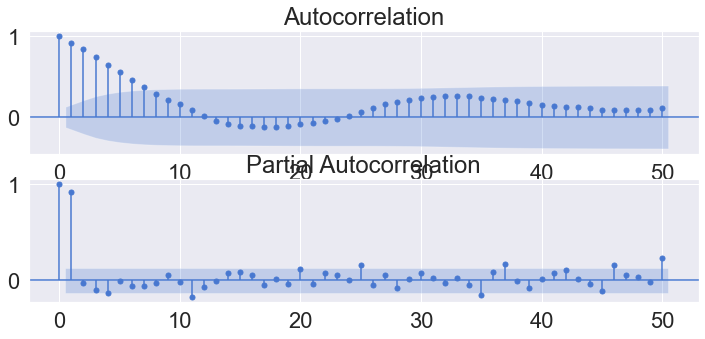

In [5]:
# Data Loading
location = os.path.join(os.getcwd(),'Data','CryptoCurrency','Bitcoin.csv')
df = pd.read_csv(location, index_col='Date')
df.index = pd.to_datetime(df.index)
df = df[['Close']].copy()

# Reshape
df_X, df_Y = reshape_1Dto2Dseq(df, seq_length=SEQUENCE)
df_Y.columns = Y_colname
df = pd.concat([df_Y, df_X], axis=1)

# Modeling
test_size = int(df.shape[0] * TEST_RATIO)

Y_real, Y_pred = pd.DataFrame(), pd.DataFrame()
X_real = pd.DataFrame()
spliter = TimeSeriesSplit(gap=0, n_splits=test_size, test_size=1)
for idx, (train_index, test_index) in tqdm(enumerate(spliter.split(df)), total=test_size):
    # Train / Test Split
    df_train = df.iloc[train_index[:-test_size],:]
    df_val = df.iloc[train_index[-test_size:],:]
    df_test = df.iloc[test_index,:]

    # X / Y Split
    X_colname = [i for i in df.columns if i not in Y_colname]
    Y_train, X_train = df_train[Y_colname], df_train[X_colname]
    Y_val, X_val = df_val[Y_colname], df_val[X_colname]
    Y_test, X_test = df_test[Y_colname], df_test[X_colname]
        
    # Scaling
    scaler_fit = scaler.fit(X_train)
    X_train = scaler_fit.transform(X_train)
    X_val = scaler_fit.transform(X_val)
    X_test = scaler_fit.transform(X_test)
    
    # MLP
    inputs = Input(shape=(X_train.shape[1],))
    hiddens = Dense(128, activation='relu')(inputs)
    hiddens = Dropout(DROPOUT_RATIO)(hiddens)
    # hiddens = Dense(256, activation='relu')(hiddens)
    # hiddens = Dropout(DROPOUT_RATIO)(hiddens)
    # hiddens = Dense(128, activation='relu')(hiddens)
    # hiddens = Dropout(DROPOUT_RATIO)(hiddens)
    hiddens = Dense(64, activation='relu')(hiddens)
    hiddens = Dropout(DROPOUT_RATIO)(hiddens)
    outputs = Dense(1)(hiddens)
    algo_MLP = Model(inputs, outputs)
    
    if (idx+1) == test_size:
        algo_MLP.summary()
        display(plot_model(algo_MLP, to_file=RESULT_LOCATION+'MLP.png', 
                           show_shapes=True, dpi=RESULT_DPI))
    
    # Learning
    CALLBACK = [callbacks.EarlyStopping(monitor='val_loss', mode='min', 
                                        patience=EARLYSTOP_PATIENT, verbose=0),
                callbacks.ModelCheckpoint(monitor='val_loss', mode='min', save_best_only=True, 
                                          filepath=RESULT_LOCATION+'MLP_Forward.h5')]
    
    algo_MLP.compile(loss='mse', optimizer='adam',
                     metrics=['mae', 'mse', 'mape'])
    algo_MLPfit = algo_MLP.fit(X_train, Y_train, 
                               batch_size=BATCH_SIZE, epochs=EPOCHS,
                               validation_data=(X_val, Y_val),
                               verbose=VERBOSE,
                               callbacks=[CALLBACK])
    
    # Best Loading
    algo_MLP = load_model(RESULT_LOCATION+'MLP_Forward.h5')
    
    if (idx+1) == test_size:
        evaluation_reg_LearningPlot(algo_MLPfit)
    
    # Prediction
    Y_tepred = algo_MLP.predict(X_test)
    
    # Rearrange
    X_real = pd.concat([X_real, pd.DataFrame(X_test, index=Y_test.index, 
                                             columns=X_colname)], axis=0)
    Y_real = pd.concat([Y_real, Y_test], axis=0)
    Y_pred = pd.concat([Y_pred, pd.DataFrame(Y_tepred, index=Y_test.index,
                                             columns=Y_test.columns)], axis=0)
    
# Evaluation
evaluation_reg_PredPlot(Y_real, Y_pred, title='MLP', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_real, Y_pred)
display(Score)

# Error Analysis
Resid_te.rename(columns={Y_colname[0]:'Error'}, inplace=True)
ErrorResult = error_analysis(Resid_te, X_real, graph_on=True)
display(ErrorResult)

# Summary
Score_MLP = Score.copy()
Y_pred_MLP = Y_pred.copy()
Error_MLP = ErrorResult.copy()

## CNN

100%|███████████████████████████████████████████████████████████████████████████████▋| 238/239 [31:06<00:09,  9.15s/it]

Model: "model_477"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_478 (InputLayer)       [(None, 20, 20)]          0         
_________________________________________________________________
conv1d_476 (Conv1D)          (None, 20, 128)           51328     
_________________________________________________________________
max_pooling1d_476 (MaxPoolin (None, 10, 128)           0         
_________________________________________________________________
dropout_954 (Dropout)        (None, 10, 128)           0         
_________________________________________________________________
conv1d_477 (Conv1D)          (None, 10, 64)            163904    
_________________________________________________________________
max_pooling1d_477 (MaxPoolin (None, 5, 64)             0         
_________________________________________________________________
dropout_955 (Dropout)        (None, 5, 64)             0 

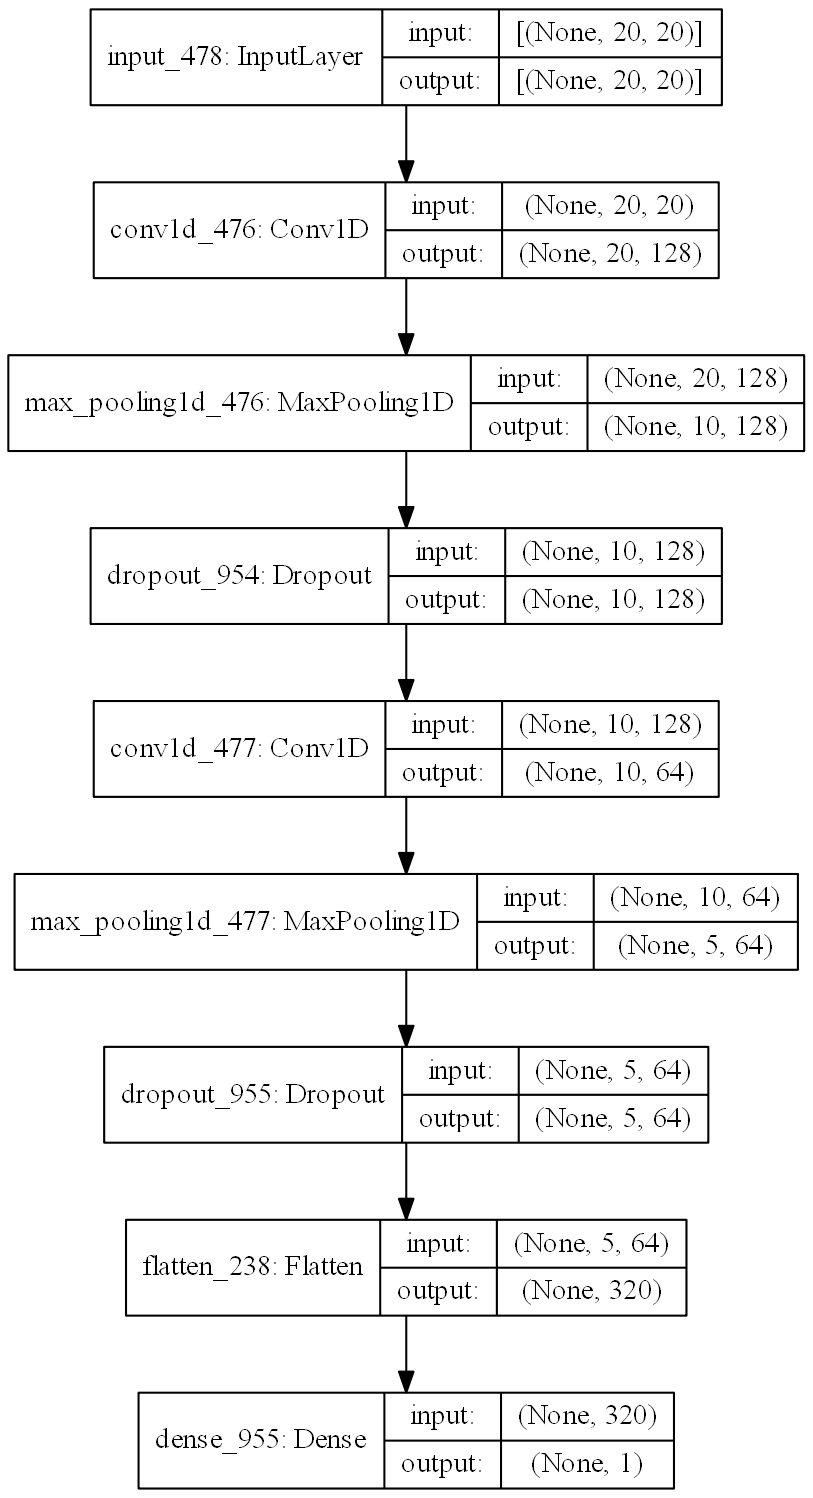

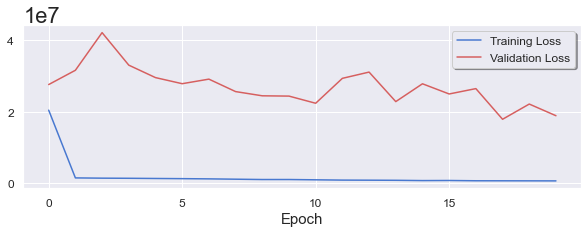

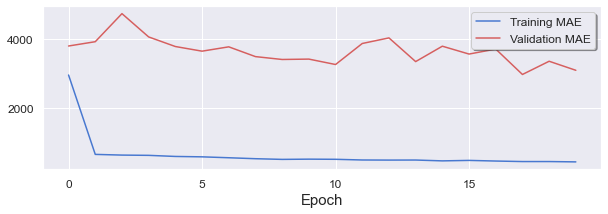

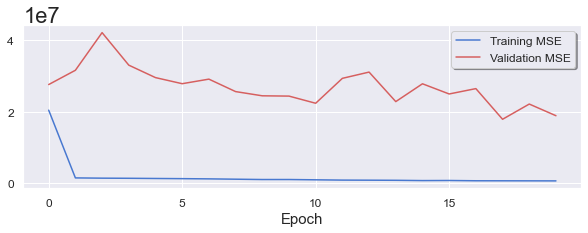

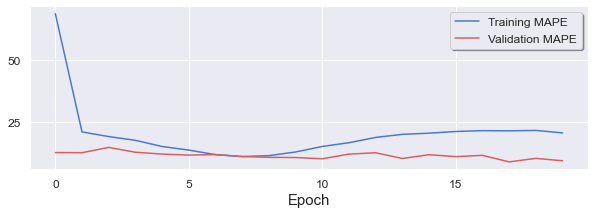

100%|████████████████████████████████████████████████████████████████████████████████| 239/239 [31:16<00:00,  7.85s/it]


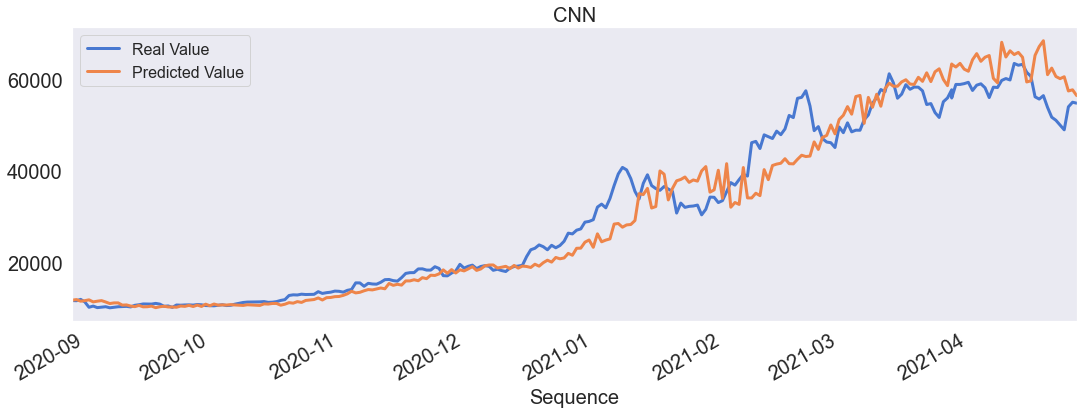

,MAE,MSE,MAPE
Score,"3,328.86","22,806,284.86",0.10


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

,Stationarity_adf,Stationarity_kpss,Normality,Autocorr(lag1),Autocorr(lag5),Autocorr(lag10),Autocorr(lag50),Heteroscedasticity
Test Statistics,-3.30,0.32,0.96,172.40,613.48,796.94,884.29,31.76
p-value,0.02,0.10,0.00,0.00,0.00,0.00,0.00,0.00
Used Lag,10.00,15.00,NaN,NaN,NaN,NaN,NaN,NaN
Used Observations,228.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Critical Value(1%),-3.46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Maximum Information Criteria,"4,145.30",NaN,NaN,NaN,NaN,NaN,NaN,NaN
Critical Value(10%),NaN,0.35,NaN,NaN,NaN,NaN,NaN,NaN
Alternative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,two-sided


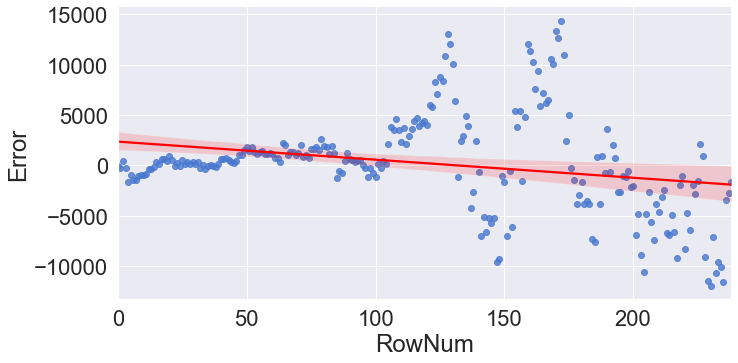

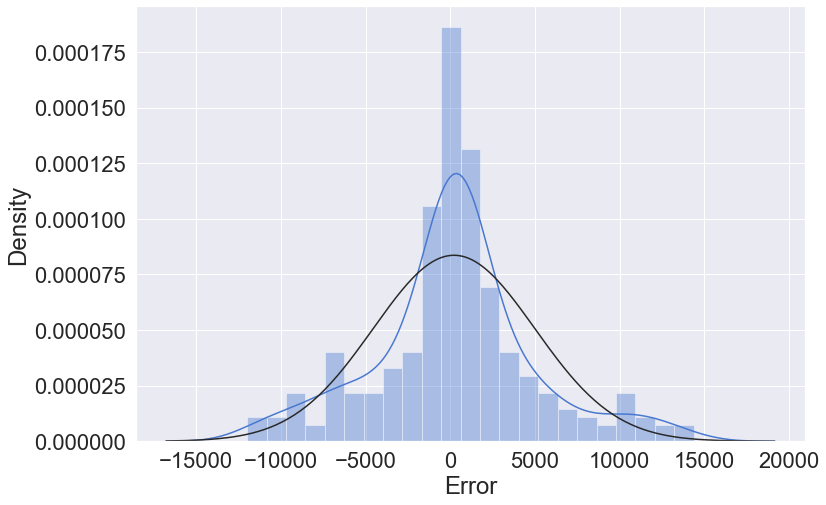

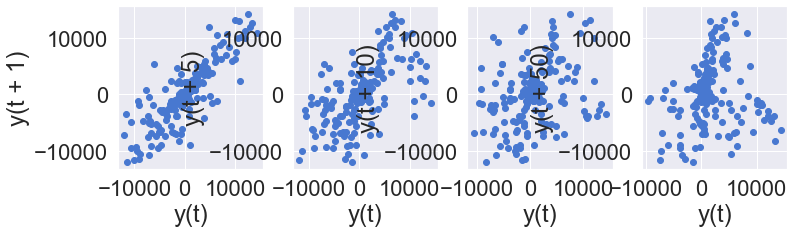

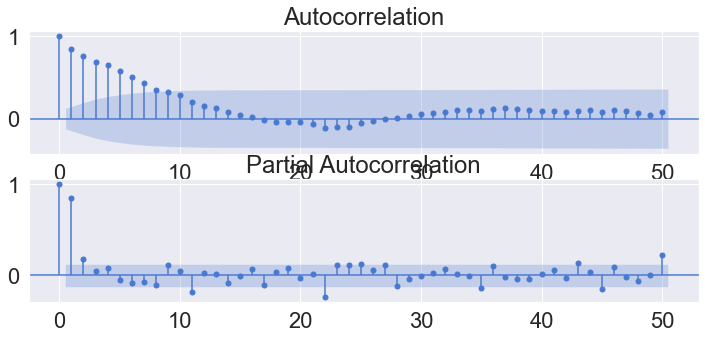

In [6]:
# Data Loading
location = os.path.join(os.getcwd(),'Data','CryptoCurrency','Bitcoin.csv')
df = pd.read_csv(location, index_col='Date')
df.index = pd.to_datetime(df.index)
df = df[['Close']].copy()

# Reshape
df_X, df_Y = reshape_1Dto2Dseq(df, seq_length=SEQUENCE)
df_Y.columns = Y_colname
df = pd.concat([df_Y, df_X], axis=1)

# Modeling
test_size = int(df.shape[0] * TEST_RATIO)

Y_real, Y_pred = pd.DataFrame(), pd.DataFrame()
X_real = pd.DataFrame()
spliter = TimeSeriesSplit(gap=0, n_splits=test_size, test_size=1)
for idx, (train_index, test_index) in tqdm(enumerate(spliter.split(df)), total=test_size):
    # Train / Test Split
    df_train = df.iloc[train_index[:-test_size],:]
    df_val = df.iloc[train_index[-test_size:],:]
    df_test = df.iloc[test_index[0]-SEQUENCE+1:test_index[0]+1,:]

    # X / Y Split
    X_colname = [i for i in df.columns if i not in Y_colname]
    Y_train, X_train = df_train[Y_colname], df_train[X_colname]
    Y_val, X_val = df_val[Y_colname], df_val[X_colname]
    Y_test, X_test = df_test[Y_colname], df_test[X_colname]
        
    # Scaling
    scaler_fit = scaler.fit(X_train)
    X_train = scaler_fit.transform(X_train)
    X_val = scaler_fit.transform(X_val)
    X_test = scaler_fit.transform(X_test)
    
    # Reshape
    X_real = pd.concat([X_real, 
                        pd.DataFrame(X_test, index=Y_test.index, columns=X_colname).iloc[[-1],:]], axis=0)
#     if idx != 0: 
#         Y_val.iloc[-1,0] = Y_tepred # reflect predicted value to val set (otherwise real one)
    X, Y = reshape_2Dto3Dseq(np.concatenate((X_train, X_val), axis=0),
                             pd.concat([Y_train, Y_val], axis=0), SEQUENCE)
    X_train, Y_train = X[:-test_size,:,:], Y.iloc[:-test_size,:]
    X_val, Y_val = X[-test_size:,:,:], Y.iloc[-test_size:,:]
    X, Y = reshape_2Dto3Dseq(X_test, Y_test, SEQUENCE)
    X_test, Y_test = X[-1:,:,:], Y.iloc[-1:,:]
    
    # CNN
    inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
    hiddens = Conv1D(128, kernel_size=X_train.shape[1], padding='same', activation='relu')(inputs)
    # hiddens = Conv1D(256, kernel_size=X_train.shape[1], padding='same', activation='relu')(hiddens)
    hiddens = MaxPooling1D(pool_size=2)(hiddens)
    hiddens = Dropout(DROPOUT_RATIO)(hiddens)
    # hiddens = Conv1D(128, kernel_size=X_train.shape[1], padding='same', activation='relu')(hiddens)
    hiddens = Conv1D(64, kernel_size=X_train.shape[1], padding='same', activation='relu')(hiddens)
    hiddens = MaxPooling1D(pool_size=2)(hiddens)
    hiddens = Dropout(DROPOUT_RATIO)(hiddens)
    hiddens = Flatten()(hiddens)
    outputs = Dense(1)(hiddens)
    algo_CNN = Model(inputs, outputs)
    
    if (idx+1) == test_size:
        algo_CNN.summary()
        display(plot_model(algo_CNN, to_file=RESULT_LOCATION+'CNN.png', 
                           show_shapes=True, dpi=RESULT_DPI))
    
    # Learning
    CALLBACK = [callbacks.EarlyStopping(monitor='val_loss', mode='min', 
                                        patience=EARLYSTOP_PATIENT, verbose=0),
                callbacks.ModelCheckpoint(monitor='val_loss', mode='min', save_best_only=True, 
                                          filepath=RESULT_LOCATION+'CNN_Forward.h5')]
    
    algo_CNN.compile(loss='mse', optimizer='adam',
                     metrics=['mae', 'mse', 'mape'])
    algo_CNNfit = algo_CNN.fit(X_train, Y_train, 
                               batch_size=BATCH_SIZE, epochs=EPOCHS,
                               validation_data=(X_val, Y_val),
                               verbose=VERBOSE,
                               callbacks=[CALLBACK])
    
    # Best Loading
    algo_CNN = load_model(RESULT_LOCATION+'CNN_Forward.h5')
    
    if (idx+1) == test_size:
        evaluation_reg_LearningPlot(algo_CNNfit)
    
    # Prediction
    Y_tepred = algo_CNN.predict(X_test)
    
    # Rearrange
    Y_real = pd.concat([Y_real, Y_test], axis=0)
    Y_pred = pd.concat([Y_pred, pd.DataFrame(Y_tepred, index=Y_test.index,
                                             columns=Y_test.columns)], axis=0)
    
# Evaluation
evaluation_reg_PredPlot(Y_real, Y_pred, title='CNN', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_real, Y_pred)
display(Score)

# Error Analysis
Resid_te.rename(columns={Y_colname[0]:'Error'}, inplace=True)
ErrorResult = error_analysis(Resid_te, X_real, graph_on=True)
display(ErrorResult)

# Summary
Score_CNN = Score.copy()
Y_pred_CNN = Y_pred.copy()
Error_CNN = ErrorResult.copy()

## RNN

100%|███████████████████████████████████████████████████████████████████████████████▋| 238/239 [32:36<00:07,  7.93s/it]

Model: "model_716"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_717 (InputLayer)       [(None, 20, 20)]          0         
_________________________________________________________________
simple_rnn_476 (SimpleRNN)   (None, 20, 128)           19072     
_________________________________________________________________
dropout_1432 (Dropout)       (None, 20, 128)           0         
_________________________________________________________________
simple_rnn_477 (SimpleRNN)   (None, 20, 64)            12352     
_________________________________________________________________
dropout_1433 (Dropout)       (None, 20, 64)            0         
_________________________________________________________________
flatten_477 (Flatten)        (None, 1280)              0         
_________________________________________________________________
dense_1194 (Dense)           (None, 1)                 12

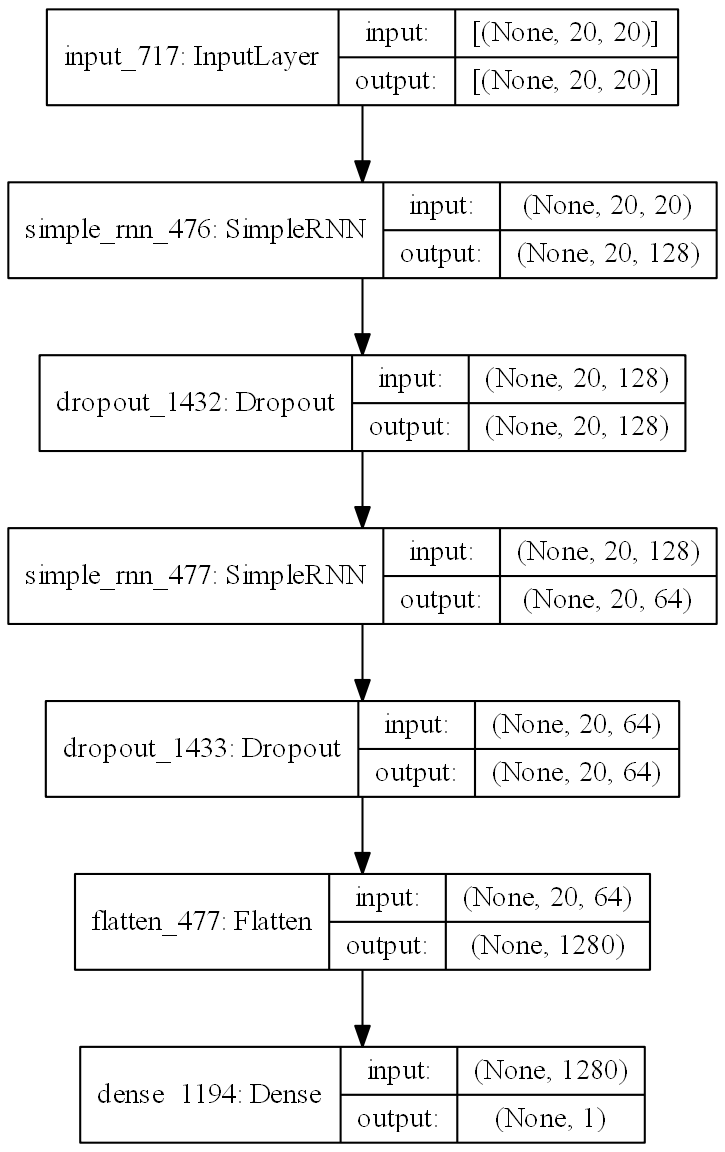

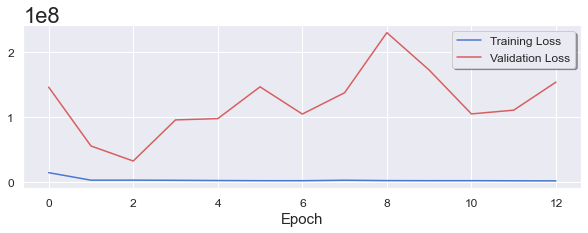

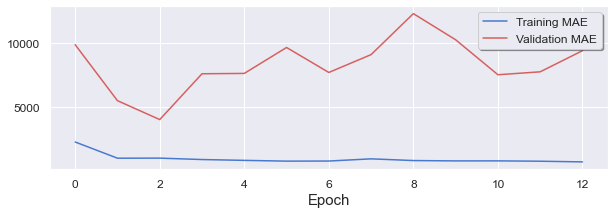

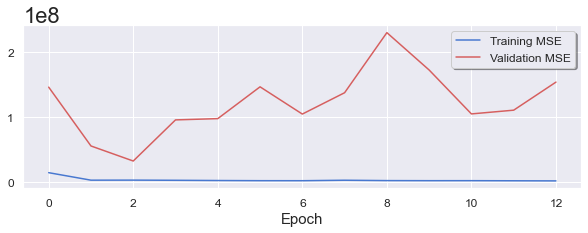

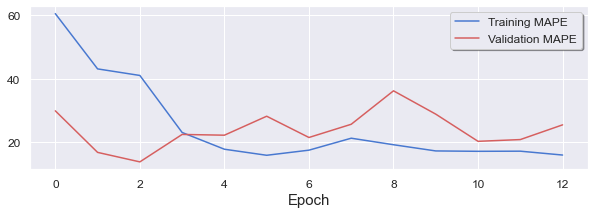

100%|████████████████████████████████████████████████████████████████████████████████| 239/239 [32:45<00:00,  8.22s/it]


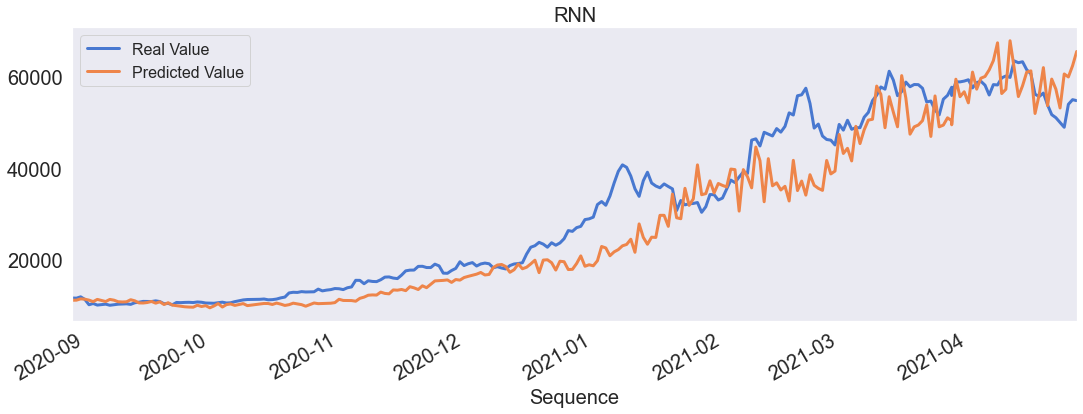

,MAE,MSE,MAPE
Score,"4,518.13","40,793,909.13",0.14


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

,Stationarity_adf,Stationarity_kpss,Normality,Autocorr(lag1),Autocorr(lag5),Autocorr(lag10),Autocorr(lag50),Heteroscedasticity
Test Statistics,-3.14,0.21,0.94,142.07,577.68,779.45,956.94,32.08
p-value,0.02,0.10,0.00,0.00,0.00,0.00,0.00,0.00
Used Lag,8.00,15.00,NaN,NaN,NaN,NaN,NaN,NaN
Used Observations,230.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Critical Value(1%),-3.46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Maximum Information Criteria,"4,216.05",NaN,NaN,NaN,NaN,NaN,NaN,NaN
Critical Value(10%),NaN,0.35,NaN,NaN,NaN,NaN,NaN,NaN
Alternative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,two-sided


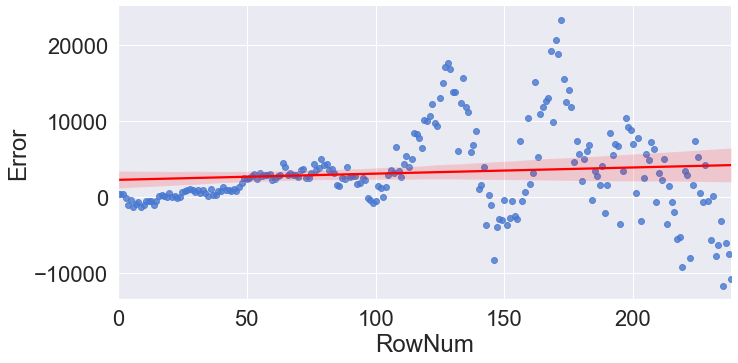

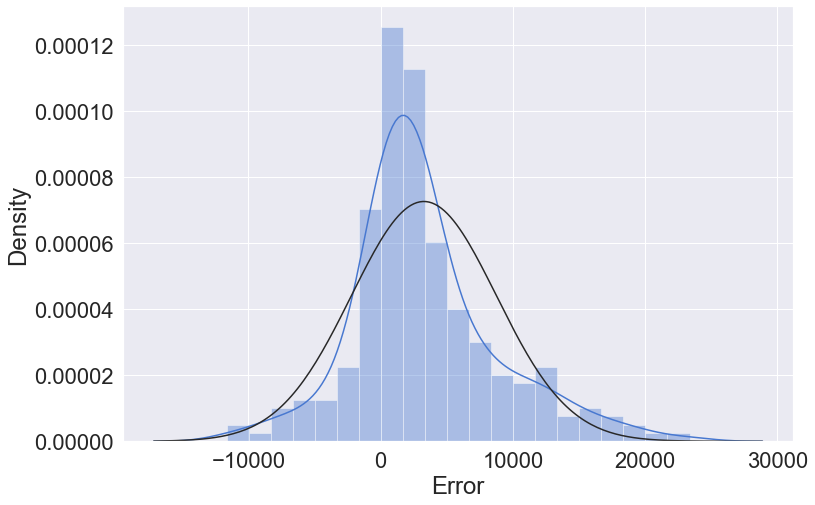

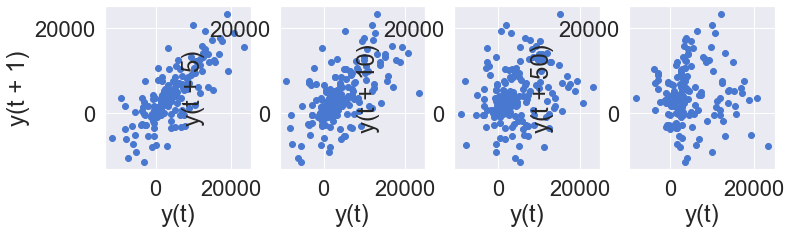

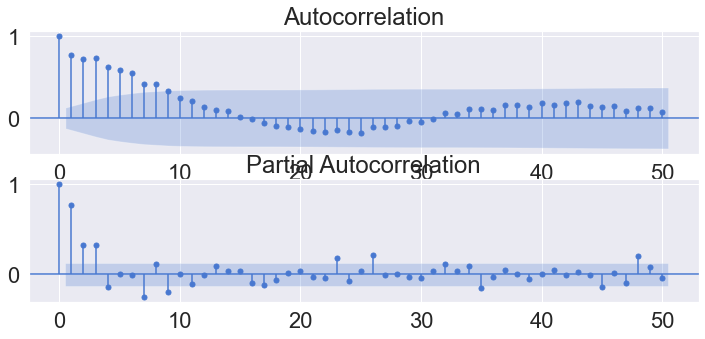

In [7]:
# Data Loading
location = os.path.join(os.getcwd(),'Data','CryptoCurrency','Bitcoin.csv')
df = pd.read_csv(location, index_col='Date')
df.index = pd.to_datetime(df.index)
df = df[['Close']].copy()

# Reshape
df_X, df_Y = reshape_1Dto2Dseq(df, seq_length=SEQUENCE)
df_Y.columns = Y_colname
df = pd.concat([df_Y, df_X], axis=1)

# Modeling
test_size = int(df.shape[0] * TEST_RATIO)

Y_real, Y_pred = pd.DataFrame(), pd.DataFrame()
X_real = pd.DataFrame()
spliter = TimeSeriesSplit(gap=0, n_splits=test_size, test_size=1)
for idx, (train_index, test_index) in tqdm(enumerate(spliter.split(df)), total=test_size):
    # Train / Test Split
    df_train = df.iloc[train_index[:-test_size],:]
    df_val = df.iloc[train_index[-test_size:],:]
    df_test = df.iloc[test_index[0]-SEQUENCE+1:test_index[0]+1,:]

    # X / Y Split
    X_colname = [i for i in df.columns if i not in Y_colname]
    Y_train, X_train = df_train[Y_colname], df_train[X_colname]
    Y_val, X_val = df_val[Y_colname], df_val[X_colname]
    Y_test, X_test = df_test[Y_colname], df_test[X_colname]
        
    # Scaling
    scaler_fit = scaler.fit(X_train)
    X_train = scaler_fit.transform(X_train)
    X_val = scaler_fit.transform(X_val)
    X_test = scaler_fit.transform(X_test)
    
    # Reshape
    X_real = pd.concat([X_real, 
                        pd.DataFrame(X_test, index=Y_test.index, columns=X_colname).iloc[[-1],:]], axis=0)
#     if idx != 0: 
#         Y_val.iloc[-1,0] = Y_tepred # reflect predicted value to val set (otherwise real one)
    X, Y = reshape_2Dto3Dseq(np.concatenate((X_train, X_val), axis=0),
                             pd.concat([Y_train, Y_val], axis=0), SEQUENCE)
    X_train, Y_train = X[:-test_size,:,:], Y.iloc[:-test_size,:]
    X_val, Y_val = X[-test_size:,:,:], Y.iloc[-test_size:,:]
    X, Y = reshape_2Dto3Dseq(X_test, Y_test, SEQUENCE)
    X_test, Y_test = X[-1:,:,:], Y.iloc[-1:,:]

    # RNN
    inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
    hiddens = SimpleRNN(128, return_sequences=True, activation='relu')(inputs)
    hiddens = Dropout(DROPOUT_RATIO)(hiddens)
    # hiddens = SimpleRNN(256, return_sequences=True, activation='relu')(hiddens)
    # hiddens = Dropout(DROPOUT_RATIO)(hiddens)
    # hiddens = SimpleRNN(128, return_sequences=True, activation='relu')(hiddens)
    # hiddens = Dropout(DROPOUT_RATIO)(hiddens)
    hiddens = SimpleRNN(64, return_sequences=True, activation='relu')(hiddens)
    hiddens = Dropout(DROPOUT_RATIO)(hiddens)
    hiddens = Flatten()(hiddens)
    outputs = Dense(1)(hiddens)
    algo_RNN = Model(inputs, outputs)
    
    if (idx+1) == test_size:
        algo_RNN.summary()
        display(plot_model(algo_RNN, to_file=RESULT_LOCATION+'RNN.png', 
                           show_shapes=True, dpi=RESULT_DPI))
    
    # Learning
    CALLBACK = [callbacks.EarlyStopping(monitor='val_loss', mode='min', 
                                        patience=EARLYSTOP_PATIENT, verbose=0),
                callbacks.ModelCheckpoint(monitor='val_loss', mode='min', save_best_only=True, 
                                          filepath=RESULT_LOCATION+'RNN_Forward.h5')]
    
    algo_RNN.compile(loss='mse', optimizer='adam',
                     metrics=['mae', 'mse', 'mape'])
    algo_RNNfit = algo_RNN.fit(X_train, Y_train, 
                               batch_size=BATCH_SIZE, epochs=EPOCHS,
                               validation_data=(X_val, Y_val),
                               verbose=VERBOSE,
                               callbacks=[CALLBACK])
    
    # Best Loading
    algo_RNN = load_model(RESULT_LOCATION+'RNN_Forward.h5')
    
    if (idx+1) == test_size:
        evaluation_reg_LearningPlot(algo_RNNfit)
    
    # Prediction
    Y_tepred = algo_RNN.predict(X_test)
    
    # Rearrange
    Y_real = pd.concat([Y_real, Y_test], axis=0)
    Y_pred = pd.concat([Y_pred, pd.DataFrame(Y_tepred, index=Y_test.index,
                                             columns=Y_test.columns)], axis=0)
    
# Evaluation
evaluation_reg_PredPlot(Y_real, Y_pred, title='RNN', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_real, Y_pred)
display(Score)

# Error Analysis
Resid_te.rename(columns={Y_colname[0]:'Error'}, inplace=True)
ErrorResult = error_analysis(Resid_te, X_real, graph_on=True)
display(ErrorResult)

# Summary
Score_RNN = Score.copy()
Y_pred_RNN = Y_pred.copy()
Error_RNN = ErrorResult.copy()

## LSTM

100%|█████████████████████████████████████████████████████████████████████████████▋| 238/239 [1:34:02<00:25, 25.67s/it]

Model: "model_955"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_956 (InputLayer)       [(None, 20, 20)]          0         
_________________________________________________________________
lstm_476 (LSTM)              (None, 20, 128)           76288     
_________________________________________________________________
dropout_1910 (Dropout)       (None, 20, 128)           0         
_________________________________________________________________
lstm_477 (LSTM)              (None, 64)                49408     
_________________________________________________________________
dropout_1911 (Dropout)       (None, 64)                0         
_________________________________________________________________
dense_1433 (Dense)           (None, 1)                 65        
Total params: 125,761
Trainable params: 125,761
Non-trainable params: 0
___________________________________________________

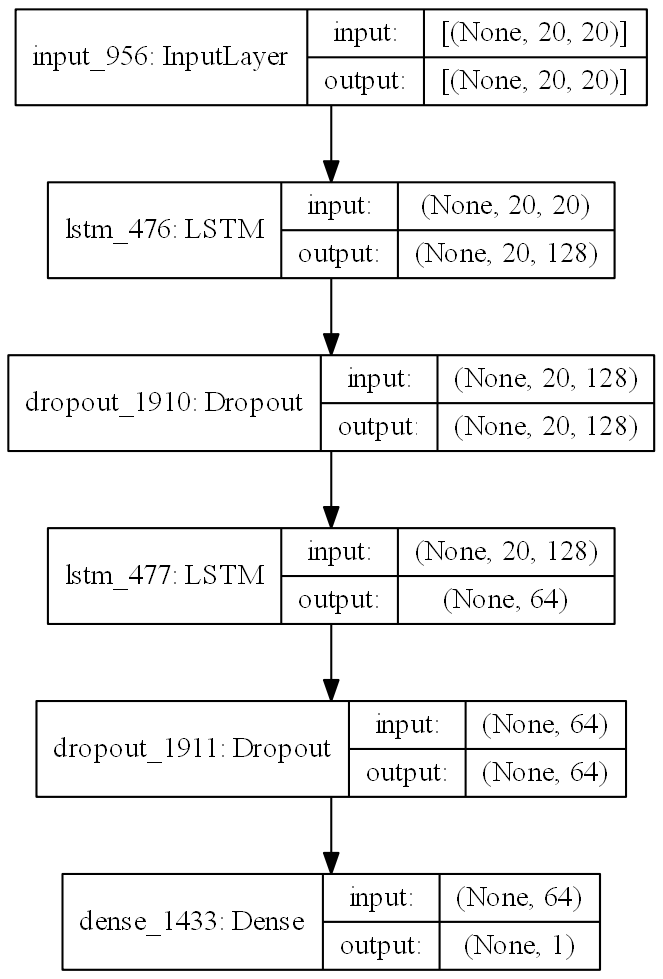

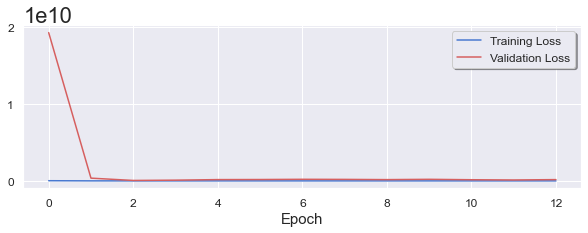

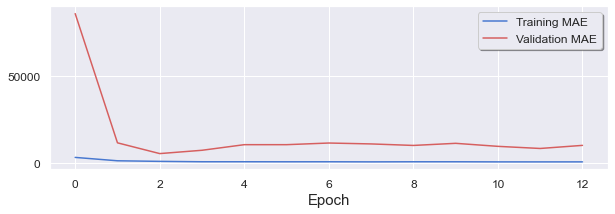

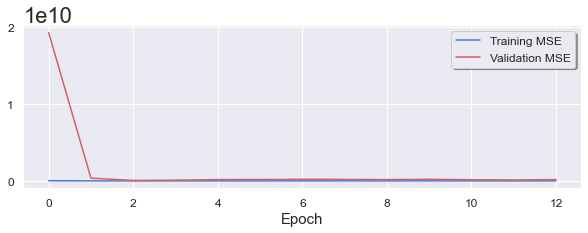

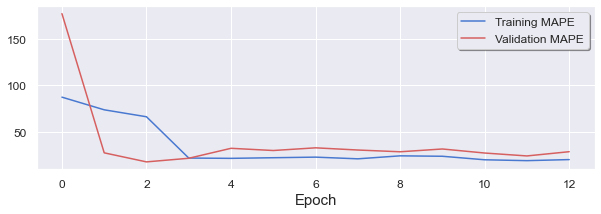

100%|██████████████████████████████████████████████████████████████████████████████| 239/239 [1:34:29<00:00, 23.72s/it]


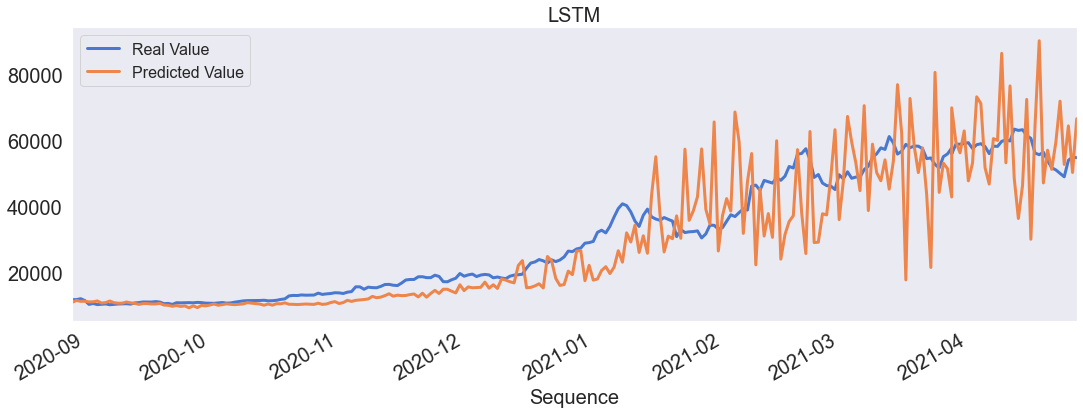

,MAE,MSE,MAPE
Score,"7,110.01","111,461,812.58",0.20


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

,Stationarity_adf,Stationarity_kpss,Normality,Autocorr(lag1),Autocorr(lag5),Autocorr(lag10),Autocorr(lag50),Heteroscedasticity
Test Statistics,-3.62,0.08,0.92,1.74,31.87,56.22,137.63,73.80
p-value,0.01,0.10,0.00,0.19,0.00,0.00,0.00,0.00
Used Lag,6.00,15.00,NaN,NaN,NaN,NaN,NaN,NaN
Used Observations,232.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Critical Value(1%),-3.46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Maximum Information Criteria,"4,753.89",NaN,NaN,NaN,NaN,NaN,NaN,NaN
Critical Value(10%),NaN,0.35,NaN,NaN,NaN,NaN,NaN,NaN
Alternative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,two-sided


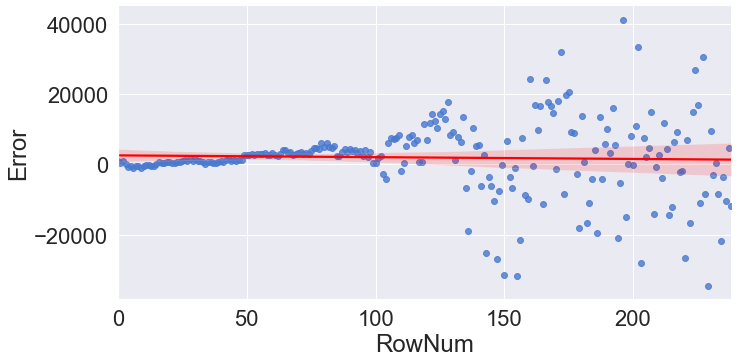

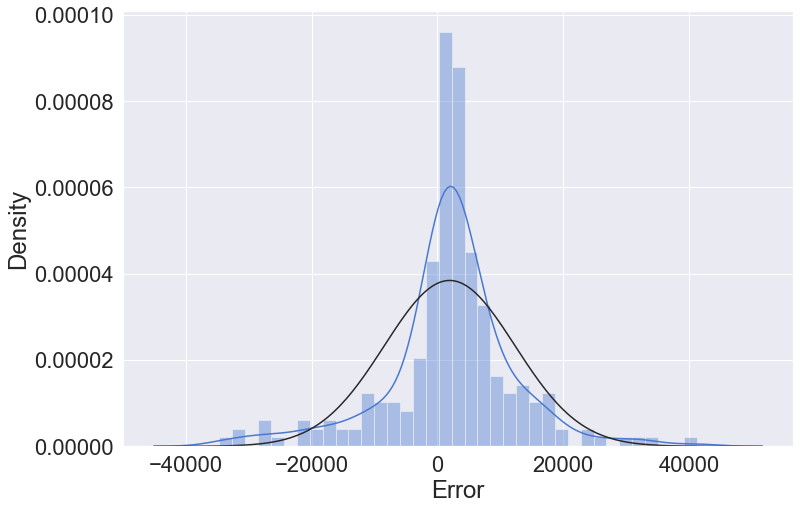

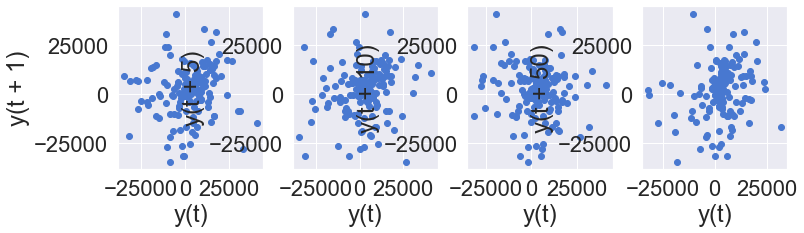

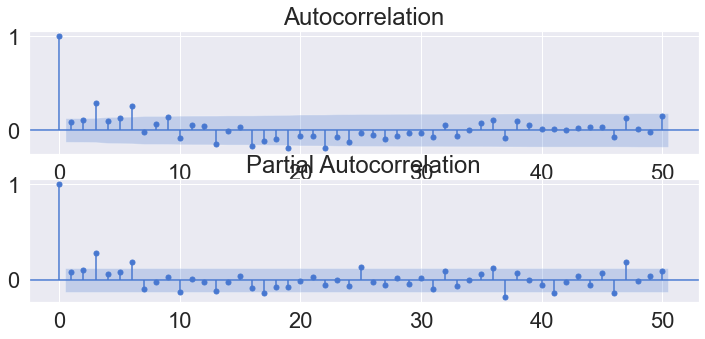

In [8]:
# Data Loading
location = os.path.join(os.getcwd(),'Data','CryptoCurrency','Bitcoin.csv')
df = pd.read_csv(location, index_col='Date')
df.index = pd.to_datetime(df.index)
df = df[['Close']].copy()

# Reshape
df_X, df_Y = reshape_1Dto2Dseq(df, seq_length=SEQUENCE)
df_Y.columns = Y_colname
df = pd.concat([df_Y, df_X], axis=1)

# Modeling
test_size = int(df.shape[0] * TEST_RATIO)

Y_real, Y_pred = pd.DataFrame(), pd.DataFrame()
X_real = pd.DataFrame()
spliter = TimeSeriesSplit(gap=0, n_splits=test_size, test_size=1)
for idx, (train_index, test_index) in tqdm(enumerate(spliter.split(df)), total=test_size):
    # Train / Test Split
    df_train = df.iloc[train_index[:-test_size],:]
    df_val = df.iloc[train_index[-test_size:],:]
    df_test = df.iloc[test_index[0]-SEQUENCE+1:test_index[0]+1,:]

    # X / Y Split
    X_colname = [i for i in df.columns if i not in Y_colname]
    Y_train, X_train = df_train[Y_colname], df_train[X_colname]
    Y_val, X_val = df_val[Y_colname], df_val[X_colname]
    Y_test, X_test = df_test[Y_colname], df_test[X_colname]
        
    # Scaling
    scaler_fit = scaler.fit(X_train)
    X_train = scaler_fit.transform(X_train)
    X_val = scaler_fit.transform(X_val)
    X_test = scaler_fit.transform(X_test)
    
    # Reshape
    X_real = pd.concat([X_real, 
                        pd.DataFrame(X_test, index=Y_test.index, columns=X_colname).iloc[[-1],:]], axis=0)
#     if idx != 0: 
#         Y_val.iloc[-1,0] = Y_tepred # reflect predicted value to val set (otherwise real one)
    X, Y = reshape_2Dto3Dseq(np.concatenate((X_train, X_val), axis=0),
                             pd.concat([Y_train, Y_val], axis=0), SEQUENCE)
    X_train, Y_train = X[:-test_size,:,:], Y.iloc[:-test_size,:]
    X_val, Y_val = X[-test_size:,:,:], Y.iloc[-test_size:,:]
    X, Y = reshape_2Dto3Dseq(X_test, Y_test, SEQUENCE)
    X_test, Y_test = X[-1:,:,:], Y.iloc[-1:,:]

    # LSTM
    inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
    hiddens = LSTM(128, return_sequences=True, activation='relu')(inputs)
    hiddens = Dropout(DROPOUT_RATIO)(hiddens)
    # hiddens = LSTM(256, return_sequences=True, activation='relu')(hiddens)
    # hiddens = Dropout(DROPOUT_RATIO)(hiddens)
    # hiddens = LSTM(128, return_sequences=True, activation='relu')(hiddens)
    # hiddens = Dropout(DROPOUT_RATIO)(hiddens)
    hiddens = LSTM(64, return_sequences=False, activation='relu')(hiddens)
    hiddens = Dropout(DROPOUT_RATIO)(hiddens)
    outputs = Dense(1)(hiddens)
    algo_LSTM = Model(inputs, outputs)
    
    if (idx+1) == test_size:
        algo_LSTM.summary()
        display(plot_model(algo_LSTM, to_file=RESULT_LOCATION+'LSTM.png', 
                           show_shapes=True, dpi=RESULT_DPI))
    
    # Learning
    CALLBACK = [callbacks.EarlyStopping(monitor='val_loss', mode='min', 
                                        patience=EARLYSTOP_PATIENT, verbose=0),
                callbacks.ModelCheckpoint(monitor='val_loss', mode='min', save_best_only=True, 
                                          filepath=RESULT_LOCATION+'LSTM_Forward.h5')]
    
    algo_LSTM.compile(loss='mse', optimizer='adam',
                     metrics=['mae', 'mse', 'mape'])
    algo_LSTMfit = algo_LSTM.fit(X_train, Y_train, 
                               batch_size=BATCH_SIZE, epochs=EPOCHS,
                               validation_data=(X_val, Y_val),
                               verbose=VERBOSE,
                               callbacks=[CALLBACK])
    
    # Best Loading
    algo_LSTM = load_model(RESULT_LOCATION+'LSTM_Forward.h5')
    
    if (idx+1) == test_size:
        evaluation_reg_LearningPlot(algo_LSTMfit)
    
    # Prediction
    Y_tepred = algo_LSTM.predict(X_test)
    
    # Rearrange
    Y_real = pd.concat([Y_real, Y_test], axis=0)
    Y_pred = pd.concat([Y_pred, pd.DataFrame(Y_tepred, index=Y_test.index,
                                             columns=Y_test.columns)], axis=0)
    
# Evaluation
evaluation_reg_PredPlot(Y_real, Y_pred, title='LSTM', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_real, Y_pred)
display(Score)

# Error Analysis
Resid_te.rename(columns={Y_colname[0]:'Error'}, inplace=True)
ErrorResult = error_analysis(Resid_te, X_real, graph_on=True)
display(ErrorResult)

# Summary
Score_LSTM = Score.copy()
Y_pred_LSTM = Y_pred.copy()
Error_LSTM = ErrorResult.copy()

## GRU

100%|█████████████████████████████████████████████████████████████████████████████▋| 238/239 [1:27:50<00:18, 18.80s/it]

Model: "model_1194"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1195 (InputLayer)      [(None, 20, 20)]          0         
_________________________________________________________________
gru_476 (GRU)                (None, 20, 128)           57600     
_________________________________________________________________
dropout_2388 (Dropout)       (None, 20, 128)           0         
_________________________________________________________________
gru_477 (GRU)                (None, 64)                37248     
_________________________________________________________________
dropout_2389 (Dropout)       (None, 64)                0         
_________________________________________________________________
dense_1672 (Dense)           (None, 1)                 65        
Total params: 94,913
Trainable params: 94,913
Non-trainable params: 0
____________________________________________________

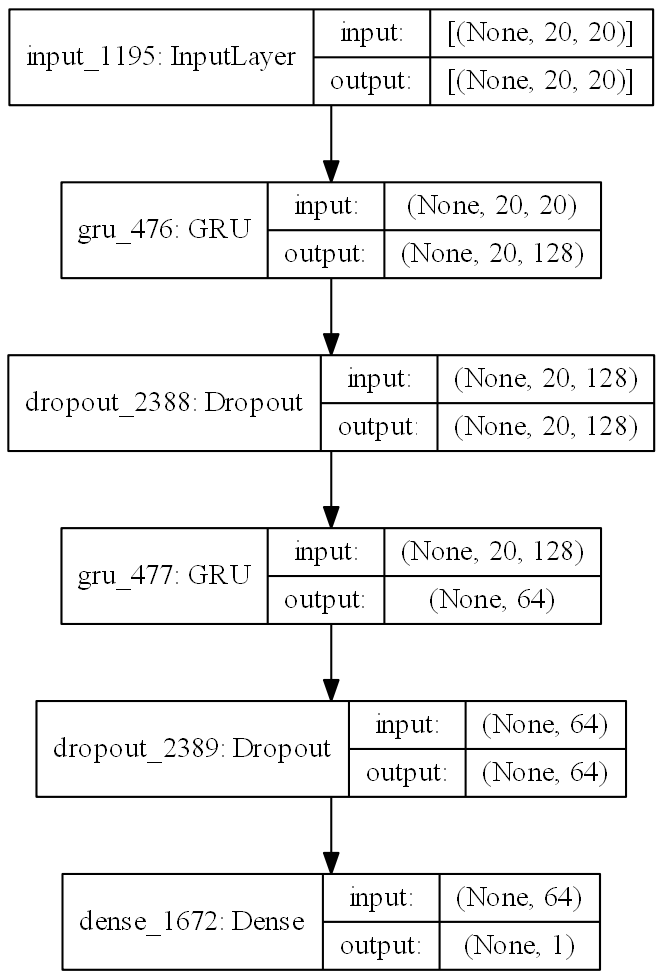

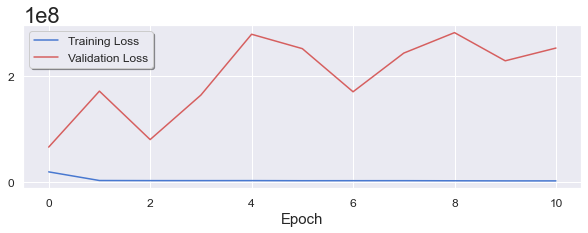

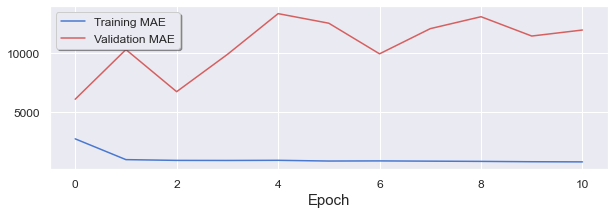

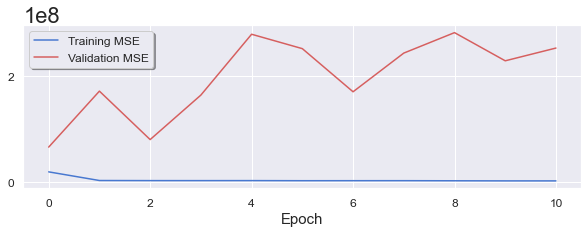

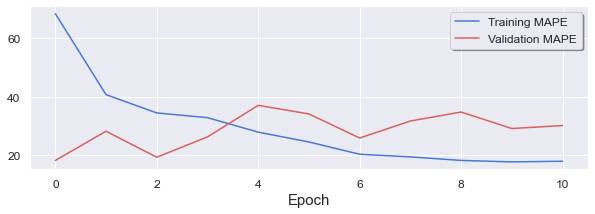

100%|██████████████████████████████████████████████████████████████████████████████| 239/239 [1:28:09<00:00, 22.13s/it]


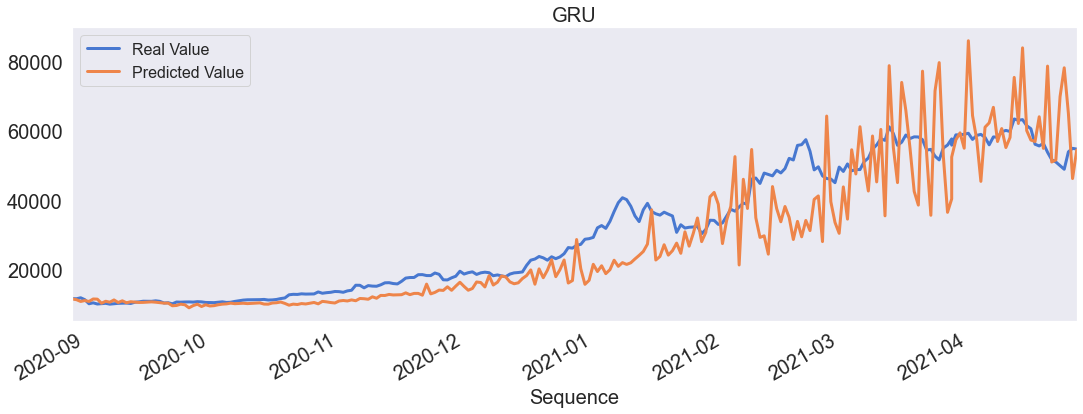

,MAE,MSE,MAPE
Score,"6,385.80","87,381,693.07",0.18


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

,Stationarity_adf,Stationarity_kpss,Normality,Autocorr(lag1),Autocorr(lag5),Autocorr(lag10),Autocorr(lag50),Heteroscedasticity
Test Statistics,-3.58,0.22,0.90,31.63,106.77,189.46,261.45,58.93
p-value,0.01,0.10,0.00,0.00,0.00,0.00,0.00,0.00
Used Lag,15.00,15.00,NaN,NaN,NaN,NaN,NaN,NaN
Used Observations,223.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Critical Value(1%),-3.46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Maximum Information Criteria,"4,632.83",NaN,NaN,NaN,NaN,NaN,NaN,NaN
Critical Value(10%),NaN,0.35,NaN,NaN,NaN,NaN,NaN,NaN
Alternative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,two-sided


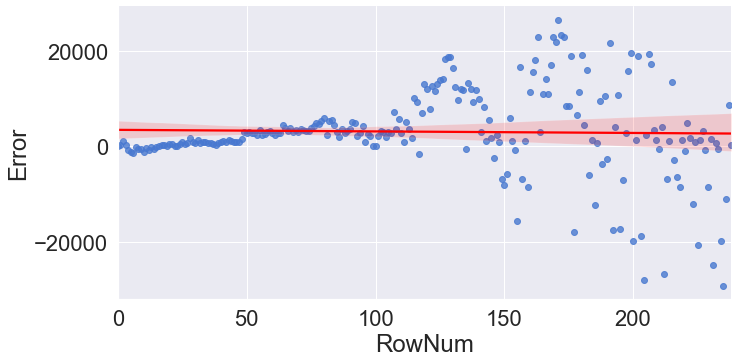

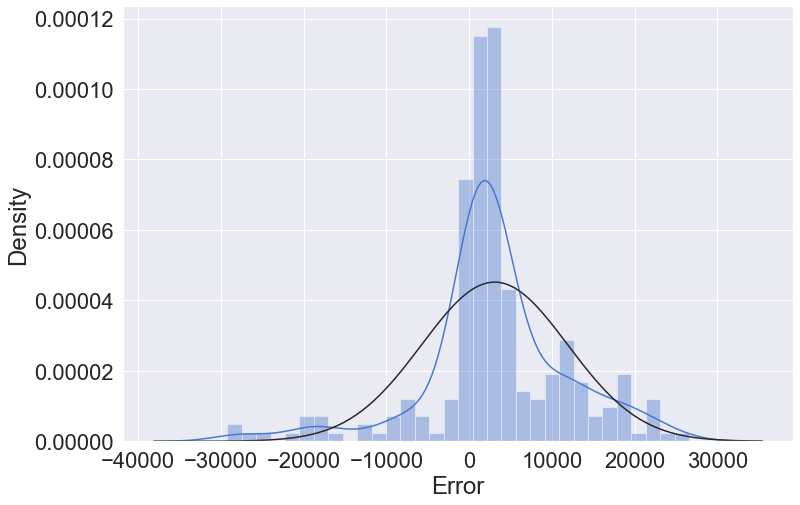

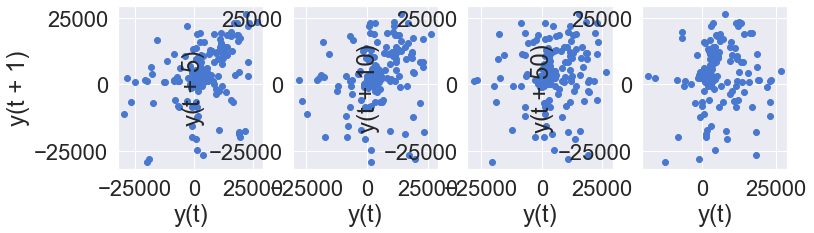

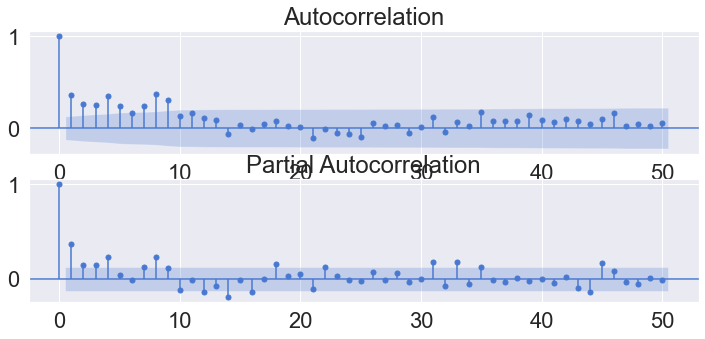

In [9]:
# Data Loading
location = os.path.join(os.getcwd(),'Data','CryptoCurrency','Bitcoin.csv')
df = pd.read_csv(location, index_col='Date')
df.index = pd.to_datetime(df.index)
df = df[['Close']].copy()

# Reshape
df_X, df_Y = reshape_1Dto2Dseq(df, seq_length=SEQUENCE)
df_Y.columns = Y_colname
df = pd.concat([df_Y, df_X], axis=1)

# Modeling
test_size = int(df.shape[0] * TEST_RATIO)

Y_real, Y_pred = pd.DataFrame(), pd.DataFrame()
X_real = pd.DataFrame()
spliter = TimeSeriesSplit(gap=0, n_splits=test_size, test_size=1)
for idx, (train_index, test_index) in tqdm(enumerate(spliter.split(df)), total=test_size):
    # Train / Test Split
    df_train = df.iloc[train_index[:-test_size],:]
    df_val = df.iloc[train_index[-test_size:],:]
    df_test = df.iloc[test_index[0]-SEQUENCE+1:test_index[0]+1,:]

    # X / Y Split
    X_colname = [i for i in df.columns if i not in Y_colname]
    Y_train, X_train = df_train[Y_colname], df_train[X_colname]
    Y_val, X_val = df_val[Y_colname], df_val[X_colname]
    Y_test, X_test = df_test[Y_colname], df_test[X_colname]
        
    # Scaling
    scaler_fit = scaler.fit(X_train)
    X_train = scaler_fit.transform(X_train)
    X_val = scaler_fit.transform(X_val)
    X_test = scaler_fit.transform(X_test)
    
    # Reshape
    X_real = pd.concat([X_real, 
                        pd.DataFrame(X_test, index=Y_test.index, columns=X_colname).iloc[[-1],:]], axis=0)
#     if idx != 0: 
#         Y_val.iloc[-1,0] = Y_tepred # reflect predicted value to val set (otherwise real one)
    X, Y = reshape_2Dto3Dseq(np.concatenate((X_train, X_val), axis=0),
                             pd.concat([Y_train, Y_val], axis=0), SEQUENCE)
    X_train, Y_train = X[:-test_size,:,:], Y.iloc[:-test_size,:]
    X_val, Y_val = X[-test_size:,:,:], Y.iloc[-test_size:,:]
    X, Y = reshape_2Dto3Dseq(X_test, Y_test, SEQUENCE)
    X_test, Y_test = X[-1:,:,:], Y.iloc[-1:,:]

    # GRU
    inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
    hiddens = GRU(128, return_sequences=True, activation='relu')(inputs)
    hiddens = Dropout(DROPOUT_RATIO)(hiddens)
    # hiddens = GRU(256, return_sequences=True, activation='relu')(hiddens)
    # hiddens = Dropout(DROPOUT_RATIO)(hiddens)
    # hiddens = GRU(128, return_sequences=True, activation='relu')(hiddens)
    # hiddens = Dropout(DROPOUT_RATIO)(hiddens)
    hiddens = GRU(64, return_sequences=False, activation='relu')(hiddens)
    hiddens = Dropout(DROPOUT_RATIO)(hiddens)
    outputs = Dense(1)(hiddens)
    algo_GRU = Model(inputs, outputs)
    
    if (idx+1) == test_size:
        algo_GRU.summary()
        display(plot_model(algo_GRU, to_file=RESULT_LOCATION+'LSTM.png', 
                           show_shapes=True, dpi=RESULT_DPI))
    
    # Learning
    CALLBACK = [callbacks.EarlyStopping(monitor='val_loss', mode='min', 
                                        patience=EARLYSTOP_PATIENT, verbose=0),
                callbacks.ModelCheckpoint(monitor='val_loss', mode='min', save_best_only=True, 
                                          filepath=RESULT_LOCATION+'GRU_Forward.h5')]
    
    algo_GRU.compile(loss='mse', optimizer='adam',
                     metrics=['mae', 'mse', 'mape'])
    algo_GRUfit = algo_GRU.fit(X_train, Y_train, 
                               batch_size=BATCH_SIZE, epochs=EPOCHS,
                               validation_data=(X_val, Y_val),
                               verbose=VERBOSE,
                               callbacks=[CALLBACK])
    
    # Best Loading
    algo_GRU = load_model(RESULT_LOCATION+'GRU_Forward.h5')
    
    if (idx+1) == test_size:
        evaluation_reg_LearningPlot(algo_GRUfit)
    
    # Prediction
    Y_tepred = algo_GRU.predict(X_test)
    
    # Rearrange
    Y_real = pd.concat([Y_real, Y_test], axis=0)
    Y_pred = pd.concat([Y_pred, pd.DataFrame(Y_tepred, index=Y_test.index,
                                             columns=Y_test.columns)], axis=0)
    
# Evaluation
evaluation_reg_PredPlot(Y_real, Y_pred, title='GRU', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_real, Y_pred)
display(Score)

# Error Analysis
Resid_te.rename(columns={Y_colname[0]:'Error'}, inplace=True)
ErrorResult = error_analysis(Resid_te, X_real, graph_on=True)
display(ErrorResult)

# Summary
Score_GRU = Score.copy()
Y_pred_GRU = Y_pred.copy()
Error_GRU = ErrorResult.copy()

# Result Summary

In [10]:
Score_Final = pd.concat([Score_MLP, Score_CNN, Score_RNN, Score_LSTM, Score_GRU], axis=0)
Score_Final.index = ALGO_NAMES
Score_Final

,MAE,MSE,MAPE
MLP,"3,522.29","24,421,357.08",0.11
CNN,"3,328.86","22,806,284.86",0.10
RNN,"4,518.13","40,793,909.13",0.14
LSTM,"7,110.01","111,461,812.58",0.20
GRU,"6,385.80","87,381,693.07",0.18


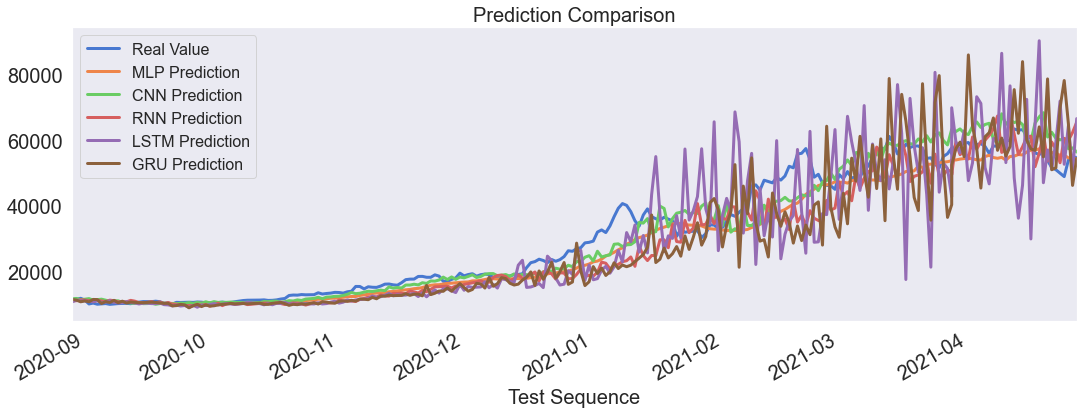

In [11]:
Y_pred_Final = pd.concat([Y_real, Y_pred_MLP, Y_pred_CNN, Y_pred_RNN, Y_pred_LSTM, Y_pred_GRU], axis=1)
Y_pred_Final.columns = ['Real Value']+[i+' Prediction' for i in ALGO_NAMES]
Y_pred_Final.plot(kind='line', figsize=(18,6), linewidth=3, fontsize=20,
                  xlim=(Y_pred_Final.index.min(),Y_pred_Final.index.max()))
plt.title('Prediction Comparison', fontsize=20)
plt.xlabel('Test Sequence', fontsize=20)
plt.ylabel('', fontsize=20)
plt.legend(fontsize=16)
plt.grid()
plt.show()

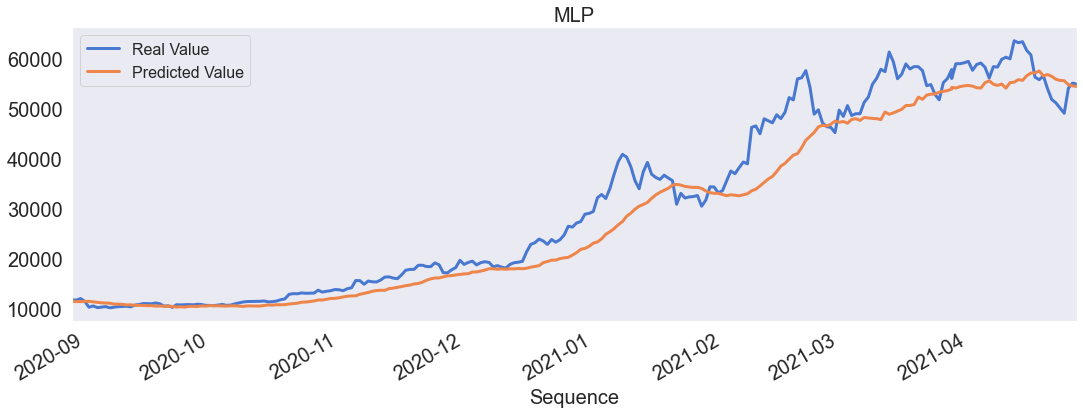

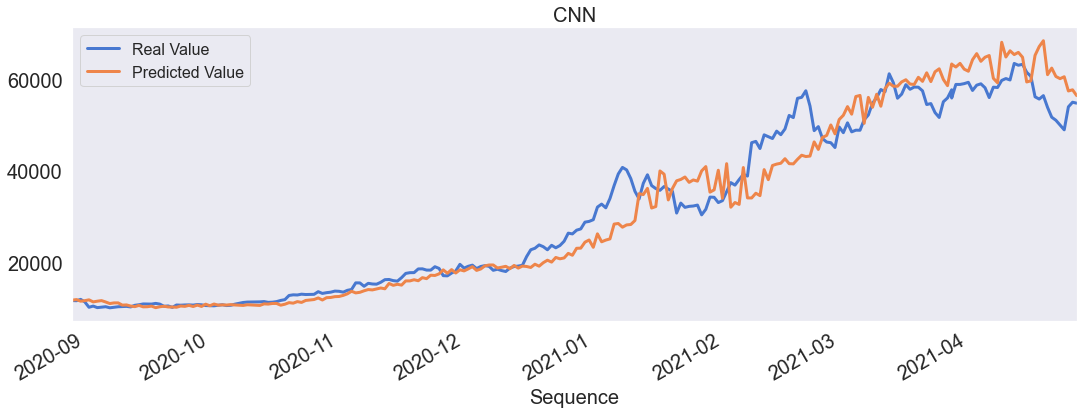

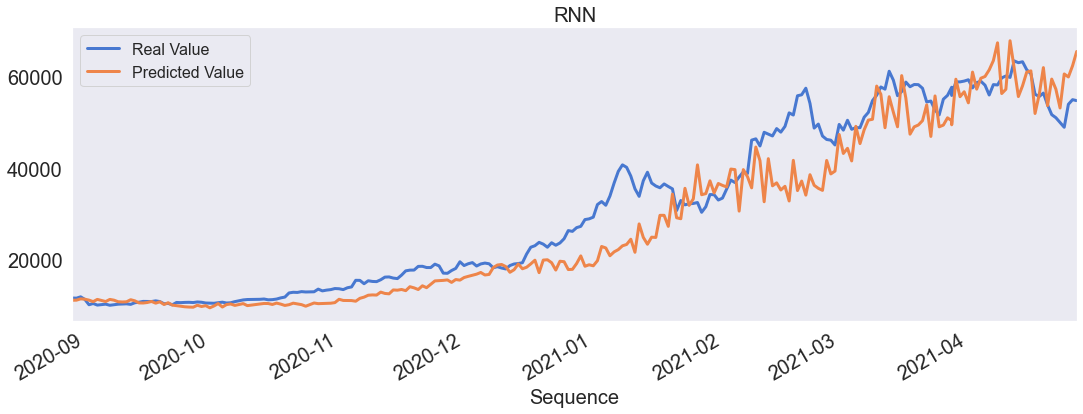

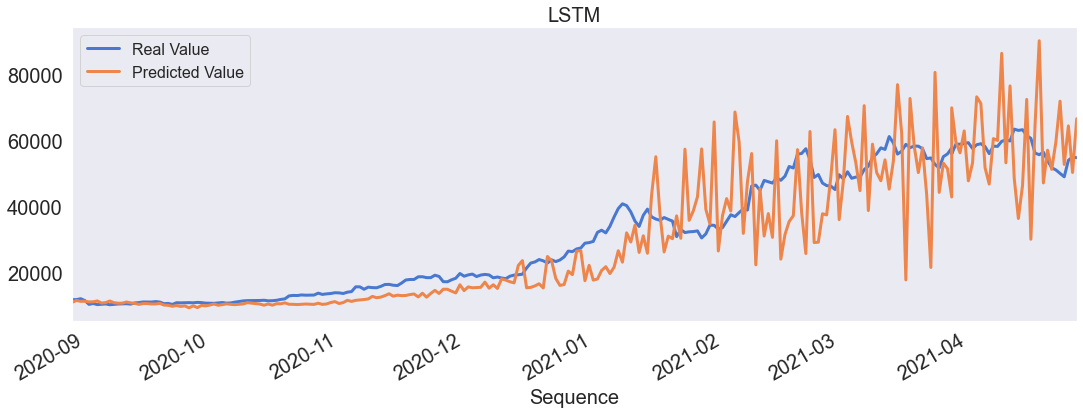

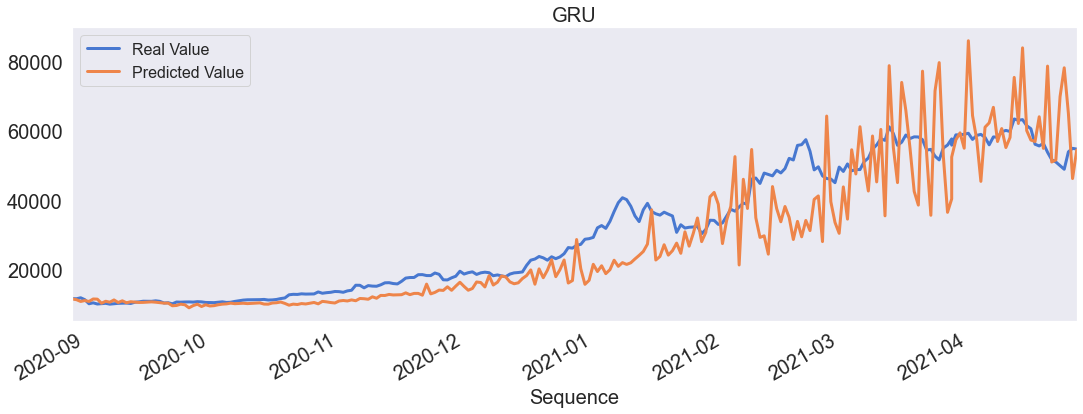

In [12]:
evaluation_reg_PredPlot(Y_real, Y_pred_MLP, title=ALGO_NAMES[0], ylabel='')
evaluation_reg_PredPlot(Y_real, Y_pred_CNN, title=ALGO_NAMES[1], ylabel='')
evaluation_reg_PredPlot(Y_real, Y_pred_RNN, title=ALGO_NAMES[2], ylabel='')
evaluation_reg_PredPlot(Y_real, Y_pred_LSTM, title=ALGO_NAMES[3], ylabel='')
evaluation_reg_PredPlot(Y_real, Y_pred_GRU, title=ALGO_NAMES[4], ylabel='')